#PDF para Json

## PDF Reader

Baixando dependencias

In [178]:
!pip install PyPDF2

In [179]:
from PyPDF2 import PdfReader

In [180]:
with open ("Pedeefe.pdf", "rb") as pdf: #abre o arquivo e define pdf como o nome do arquivo
    reader = PdfReader(pdf) #lê o arquivo e define reader como o leitor do arquivo
    np = len(reader.pages) #conta o número de páginas do arquivo e define np como o número de páginas

    for i in range(np): #looping
        page = reader.pages[i]
        texto = page.extract_text()

In [181]:
print(texto)

Davi Antonio Ramos Araujo
DESENVOLVEDOR FULL STACK
CONTATO
Telefone: 11 94136 - 4461
Email: daviramos1703@gmail.com
Github: d a v i z i n - r a
EXPERIÊNCIA
Freelancer, São Paulo
Editor de vídeo
2024 - Junho 2025
Cliente: PapiPaieTV
Edição de vídeo de Gameplay - l i n k
Cliente: LontraFrita
Edição de vídeo de História narrada - l i n k
Apaixonado por tecnologia desde cedo, formado no curso técnico em
Informática para Internet pela ETEC e atualmente curso Segurança da
Informação na FATEC São Caetano do Sul, em constante busca por
novos aprendizados e oportunidades na área de tecnologia.
TECNOLOGIAS
HTML/CSS
JavaScript
Bootstrap
PHP
C#
MySQL
Node.js
Python
React
Figma
Adobe Ps/Ai/Ae/Ap
Git / GitHub
IOT
IP/DHCP
UI/UX
PROJETOS
Trabalho de Conclusão de Curso – ETEC
Aplicativo de treinos desenvolvido com o foco em acessibilidade
de pessoas com deficiências físicas.
Tecnologias: PHP, React, JavaScript, Bootstrap, HTML5,
CSS3, MySQL.
Repositório Git - l i n k
Site Administrador de Notas – Feira

##Transformando o texto em json

In [182]:
json_texto = texto.split("\n")

In [183]:
print(json_texto)

['Davi Antonio Ramos Araujo', 'DESENVOLVEDOR FULL STACK', 'CONTATO', 'Telefone: 11 94136 - 4461', 'Email: daviramos1703@gmail.com', 'Github: d a v i z i n - r a', 'EXPERIÊNCIA', 'Freelancer, São Paulo', 'Editor de vídeo', '2024 - Junho 2025', 'Cliente: PapiPaieTV', 'Edição de vídeo de Gameplay - l i n k', 'Cliente: LontraFrita', 'Edição de vídeo de História narrada - l i n k', 'Apaixonado por tecnologia desde cedo, formado no curso técnico em', 'Informática para Internet pela ETEC e atualmente curso Segurança da', 'Informação na FATEC São Caetano do Sul, em constante busca por', 'novos aprendizados e oportunidades na área de tecnologia.', 'TECNOLOGIAS', 'HTML/CSS', 'JavaScript', 'Bootstrap', 'PHP', 'C#', 'MySQL', 'Node.js', 'Python', 'React', 'Figma', 'Adobe Ps/Ai/Ae/Ap', 'Git / GitHub', 'IOT', 'IP/DHCP', 'UI/UX', 'PROJETOS', 'Trabalho de Conclusão de Curso – ETEC', 'Aplicativo de treinos desenvolvido com o foco em acessibilidade', 'de pessoas com deficiências físicas.', 'Tecnologias: 

# Dados CSV

Instalando e importando pandas

In [184]:
!pip install pandas

In [185]:
import pandas as pd

O CSV de treino está nos arquivos - dataset.csv

Com arquivo CSV:

In [186]:
ds = pd.read_csv("dataset3.csv") #define ds como o arquivo, mas para testes executar o de baixo

In [187]:
print(ds.head(5)) #teste

                                             text       label
0                     Celular +55 (11) 92510-2141     contact
1                                Machine Learning      skills
2                    DataBridge | DevOps Engineer  experience
3  Projeto: Pipeline de dados com Airflow e Spark    projects
4         Tecnólogo em ADS - Universidade Federal   education


## Separando X e Y = Text e Label

In [188]:
X = ds["text"]
Y = ds["label"]

In [189]:
print(X[:2])
print(Y[:2])

0    Celular +55 (11) 92510-2141
1               Machine Learning
Name: text, dtype: object
0    contact
1     skills
Name: label, dtype: object


# NLP Formatação

In [190]:
import re

Criando função de filtro

In [191]:
def prep(texto):
  texto = texto.lower() #minusculo
  texto = re.sub(r"[^a-zA-Z0-9\s]", "", texto)
  tokens = texto.split() #separa em palavras
  return " ".join(tokens)

In [192]:
var = "Email: Davi@email.com" #teste

print(prep(var))

email daviemailcom


#Aplicando na dataset

In [193]:
ds["limpo"] = ds["text"].apply(prep)

In [194]:
print(ds.head())

                                             text       label  \
0                     Celular +55 (11) 92510-2141     contact   
1                                Machine Learning      skills   
2                    DataBridge | DevOps Engineer  experience   
3  Projeto: Pipeline de dados com Airflow e Spark    projects   
4         Tecnólogo em ADS - Universidade Federal   education   

                                           limpo  
0                        celular 55 11 925102141  
1                               machine learning  
2                     databridge devops engineer  
3  projeto pipeline de dados com airflow e spark  
4           tecnlogo em ads universidade federal  


In [195]:
X = ds["limpo"]

#TF-IDF

In [196]:
!pip install scikit-learn

In [197]:
from sklearn.feature_extraction.text import TfidfVectorizer

##Vetorizando X

In [198]:
vectorizer = TfidfVectorizer()
Xvet = vectorizer.fit_transform(X)

In [199]:
print(Xvet.shape)

(200000, 37980)


##Classificador

In [200]:
from sklearn.linear_model import LogisticRegression

In [201]:
model = LogisticRegression()
model.fit(Xvet, Y)

LogisticRegression()

Teste IA inicial

In [202]:
testetct = ["Curso"]
testeVet = vectorizer.transform(testetct)
predict = model.predict(testeVet)

print(predict)

['education']


Função de classificação

In [203]:
def classFunc(text):

    vet = vectorizer.transform([text])
    pred = model.predict(vet)

    return pred[0]

In [204]:
print(classFunc("Curso Machine"))

education


# Treino/Teste

In [205]:
from sklearn.model_selection import train_test_split

In [206]:
X_train, X_test, Y_train, Y_test = train_test_split( #20% teste 80% treino
    ds["limpo"],
    ds["label"],
    test_size=0.2,
    random_state=42
)

##TF-IDF aplicado

In [207]:
X_trainVet = vectorizer.fit_transform(X_train)
X_testVet = vectorizer.transform(X_test)

Treinando com o Regression

In [208]:
model = LogisticRegression()
model.fit(X_trainVet, Y_train)

LogisticRegression()

In [209]:
Ypred = model.predict(X_testVet) #Predict

##Precisão


accuracy = acertos / total

In [210]:
from sklearn.metrics import accuracy_score

In [211]:
accuracy = accuracy_score(Y_test, Ypred)
print("Accuracy:", accuracy)

Accuracy: 1.0


###Class Report

In [212]:
from sklearn.metrics import classification_report

In [213]:
print(classification_report(Y_test, Ypred))

              precision    recall  f1-score   support

       about       1.00      1.00      1.00      6666
     contact       1.00      1.00      1.00      6696
   education       1.00      1.00      1.00      6653
  experience       1.00      1.00      1.00      6600
    projects       1.00      1.00      1.00      6696
      skills       1.00      1.00      1.00      6689

    accuracy                           1.00     40000
   macro avg       1.00      1.00      1.00     40000
weighted avg       1.00      1.00      1.00     40000



###Confusion Matrix

In [214]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [244]:
cm = confusion_matrix(Y_test, Ypred)
print(cm)

[[6666    0    0    0    0    0]
 [   0 6696    0    0    0    0]
 [   0    0 6653    0    0    0]
 [   0    0    0 6600    0    0]
 [   0    0    0    0 6696    0]
 [   0    0    0    0    0 6689]]


In [216]:
import matplotlib.pyplot as plt

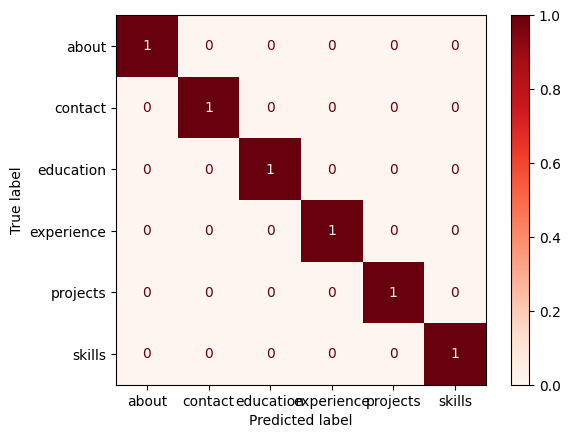

In [243]:
ConfusionMatrixDisplay.from_estimator(
    model,
    X_testVet,
    Y_test,
    cmap=plt.cm.Reds,
    normalize='true'
)

plt.show()

##Itens para treino

In [218]:
print(len(X_train))
print(len(X_test))

160000
40000


In [219]:
print(ds["label"].value_counts())

label
contact       33334
skills        33334
experience    33333
projects      33333
education     33333
about         33333
Name: count, dtype: int64


#Entrada/Saida


In [232]:
def ClassFuncLin(lines):

    results = []

    for line in lines:

        label = classFunc(line)

        results.append((line, label))

    return results

In [225]:
print(ClassFuncLin(json_texto))

[('Davi Antonio Ramos Araujo', 'skills'), ('DESENVOLVEDOR FULL STACK', 'about'), ('CONTATO', 'contact'), ('Telefone: 11 94136 - 4461', 'contact'), ('Email: daviramos1703@gmail.com', 'contact'), ('Github: d a v i z i n - r a', 'contact'), ('EXPERIÊNCIA', 'skills'), ('Freelancer, São Paulo', 'skills'), ('Editor de vídeo', 'projects'), ('2024 - Junho 2025', 'skills'), ('Cliente: PapiPaieTV', 'skills'), ('Edição de vídeo de Gameplay - l i n k', 'projects'), ('Cliente: LontraFrita', 'skills'), ('Edição de vídeo de História narrada - l i n k', 'projects'), ('Apaixonado por tecnologia desde cedo, formado no curso técnico em', 'about'), ('Informática para Internet pela ETEC e atualmente curso Segurança da', 'education'), ('Informação na FATEC São Caetano do Sul, em constante busca por', 'about'), ('novos aprendizados e oportunidades na área de tecnologia.', 'about'), ('TECNOLOGIAS', 'skills'), ('HTML/CSS', 'skills'), ('JavaScript', 'skills'), ('Bootstrap', 'skills'), ('PHP', 'skills'), ('C#', 

In [233]:
def Organizado(lines):
    results = ClassFuncLin(lines)  # sua função que já retorna (linha, label)

    agrupado = {}
    for linha, label in results:
        if label not in agrupado:
            agrupado[label] = []
        agrupado[label].append(linha)

    return agrupado

In [234]:
print(Organizado(json_texto))

{'skills': ['Davi Antonio Ramos Araujo', 'EXPERIÊNCIA', 'Freelancer, São Paulo', '2024 - Junho 2025', 'Cliente: PapiPaieTV', 'Cliente: LontraFrita', 'TECNOLOGIAS', 'HTML/CSS', 'JavaScript', 'Bootstrap', 'PHP', 'C#', 'MySQL', 'Node.js', 'Python', 'React', 'Figma', 'Adobe Ps/Ai/Ae/Ap', 'IOT', 'IP/DHCP', 'UI/UX', 'PROJETOS', 'Tecnologias: PHP, React, JavaScript, Bootstrap, HTML5,', 'CSS3, MySQL.', 'Repositório Git - l i n k', 'end)', 'Tecnologias: HTML5, CSS3, JavaScript.', 'Repositório Git - l i n k', 'processos administrativos.', 'Tecnologias: PHP, HTML5, CSS3, JavaScript, SQL.', 'Repositório Git - l i n k', 'FORMAÇÃO E CURSOS', 'FATEC SCS ', 'ETEC Prof Maria Cristina Medeiros', 'ClasseA Idiomas', 'SuperGeek', 'anos)'], 'about': ['DESENVOLVEDOR FULL STACK', 'Apaixonado por tecnologia desde cedo, formado no curso técnico em', 'Informação na FATEC São Caetano do Sul, em constante busca por', 'novos aprendizados e oportunidades na área de tecnologia.', 'Ensino médio integrado com técnico e

In [238]:
agrupado = Organizado(json_texto)
itens = []
for categoria, conteudos in agrupado.items():
    for conteudo in conteudos:
        itens.append({'Categoria': categoria, 'Conteúdo': conteudo})

DS_OG = pd.DataFrame(itens)

In [242]:
print(DS_OG[:20])

   Categoria                   Conteúdo
0     skills  Davi Antonio Ramos Araujo
1     skills                EXPERIÊNCIA
2     skills      Freelancer, São Paulo
3     skills          2024 - Junho 2025
4     skills        Cliente: PapiPaieTV
5     skills       Cliente: LontraFrita
6     skills                TECNOLOGIAS
7     skills                   HTML/CSS
8     skills                 JavaScript
9     skills                  Bootstrap
10    skills                        PHP
11    skills                         C#
12    skills                      MySQL
13    skills                    Node.js
14    skills                     Python
15    skills                      React
16    skills                      Figma
17    skills          Adobe Ps/Ai/Ae/Ap
18    skills                        IOT
19    skills                    IP/DHCP


In [249]:
lista = DS_OG[DS_OG['Categoria'] == 'skills']['Conteúdo'].tolist()
print(lista)

['Davi Antonio Ramos Araujo', 'EXPERIÊNCIA', 'Freelancer, São Paulo', '2024 - Junho 2025', 'Cliente: PapiPaieTV', 'Cliente: LontraFrita', 'TECNOLOGIAS', 'HTML/CSS', 'JavaScript', 'Bootstrap', 'PHP', 'C#', 'MySQL', 'Node.js', 'Python', 'React', 'Figma', 'Adobe Ps/Ai/Ae/Ap', 'IOT', 'IP/DHCP', 'UI/UX', 'PROJETOS', 'Tecnologias: PHP, React, JavaScript, Bootstrap, HTML5,', 'CSS3, MySQL.', 'Repositório Git - l i n k', 'end)', 'Tecnologias: HTML5, CSS3, JavaScript.', 'Repositório Git - l i n k', 'processos administrativos.', 'Tecnologias: PHP, HTML5, CSS3, JavaScript, SQL.', 'Repositório Git - l i n k', 'FORMAÇÃO E CURSOS', 'FATEC SCS ', 'ETEC Prof Maria Cristina Medeiros', 'ClasseA Idiomas', 'SuperGeek', 'anos)']
